```
# =============================================================================
# Integrantes: Arthur Meneses Neves, Danilo Oliveira Santos, Matheus Gabriel
# Viana Araujo, João Victor Vidal Barbosa, Guilherme Araujo Castro
#
# Síntese: Análise exploratória do SIM (Mortalidade Geral, 2000-2026): distribuições
# demográficas, causas de óbito, tendência anual, sazonalidade e valores ausentes.
#
# Changelog:
#   2026-09-22 - Matheus Araujo - criação do notebook
#   2026-09-23 - Matheus Araujo - um gráfico por figura; anos 2022 e 2023 sem cabeçalho
#   2026-09-24 - Matheus Araujo - comentário do escopo temporal aponta para data/README.md
# =============================================================================
```

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
from sim_utils import causabas_to_chapter, decode_idade_anos, load_sim_anos

ANOS = list(range(2000, 2027))  # 1979-1999 fora de escopo (ver Escopo temporal do projeto em data/README.md)
df = load_sim_anos("../data", ANOS)
df.shape, df.dtypes

((32629071, 9),
 TIPOBITO         int64
 DTOBITO            str
 IDADE          float64
 SEXO             int64
 RACACOR        float64
 ESC             object
 CODMUNRES        int64
 CAUSABAS           str
 ANO_ARQUIVO      int64
 dtype: object)

In [2]:
df_2000 = df[df["ANO_ARQUIVO"] == 2000]
faltantes = (df_2000.isna().mean() * 100).sort_values(ascending=False)
faltantes

ESC            19.554108
RACACOR        15.904217
IDADE           0.000317
TIPOBITO        0.000000
DTOBITO         0.000000
SEXO            0.000000
CODMUNRES       0.000000
CAUSABAS        0.000000
ANO_ARQUIVO     0.000000
dtype: float64

**Achados de qualidade de dados desta EDA (a tratar no notebook 02).**

- `ESC` e `RACACOR` têm dois tipos de "sem informação": valores realmente ausentes (`NaN`, contados como missing acima) e o código de *ignorado* (`9`), que é um valor preenchido e, portanto, **não** entra na contagem de `isna()`. `ESC == 9` é em torno de 9% a 25% dos óbitos por ano (tabela abaixo), mais que o `NaN` em vários anos.
- Em 2000 e 2001 a coluna `ESC` é lida como texto (`"1"`..`"9"`, mais os códigos raros `"A"` e `"8"`), enquanto nos demais anos é numérica; ao empilhar os anos a coluna vira tipo `object` (mistura de `str` e `float`). `ESC = 0` só aparece em alguns anos (2009-2012, 2014).
- `CODMUNRES` mistura códigos de município de 6 dígitos (ex.: `355030`) e de 7 dígitos (ex.: `3550308`, com dígito verificador) para o mesmo município: veja o top 10 mais adiante, em que São Paulo e Rio de Janeiro aparecem duas vezes. É preciso padronizar para 6 dígitos antes de usar município como atributo.
- `DTOBITO` vem em formatos diferentes por ano; `load_sim_anos` já o devolve normalizado em `ddmmaaaa` (8 dígitos). Poucas datas têm mês `00`.


In [3]:
print("ESC (valores, pooled; inclui NaN):")
print(df["ESC"].astype(str).value_counts(dropna=False).to_string())
print()
print("RACACOR (valores, pooled; inclui NaN):")
print(df["RACACOR"].value_counts(dropna=False).to_string())
print()
print("% de ESC == 9 (ignorado) por ano, 2000-2026:")
esc_ign = (df["ESC"].astype(str).isin(["9", "9.0"])).groupby(df["ANO_ARQUIVO"]).mean() * 100
print(esc_ign.round(2).to_string())

ESC (valores, pooled; inclui NaN):
ESC
2.0    6314926
3.0    6047502
1.0    4903965
4.0    4110737
NaN    3972381
9.0    3947485
5.0    1554471
9       464855
1       353039
2       341019
3       235846
0.0     231933
4        94230
5        56390
8          186
A          106

RACACOR (valores, pooled; inclui NaN):
RACACOR
1.0    16889989
4.0    11157986
2.0     2534318
NaN     1758233
3.0      192967
5.0       95573
9.0           5

% de ESC == 9 (ignorado) por ano, 2000-2026:


ANO_ARQUIVO
2000    24.55
2001    24.18
2002    23.69
2003    16.74
2004    16.17
2005    16.93
2006    16.66
2007    16.04
2008    15.21
2009    14.97
2010    14.72
2011    12.95
2012    12.30
2013    12.19
2014    12.49
2015    12.19
2016    12.17
2017    11.73
2018    11.40
2019    11.17
2020    11.49
2021    10.67
2022    10.62
2023     9.82
2024     9.17
2025     9.16
2026     9.07


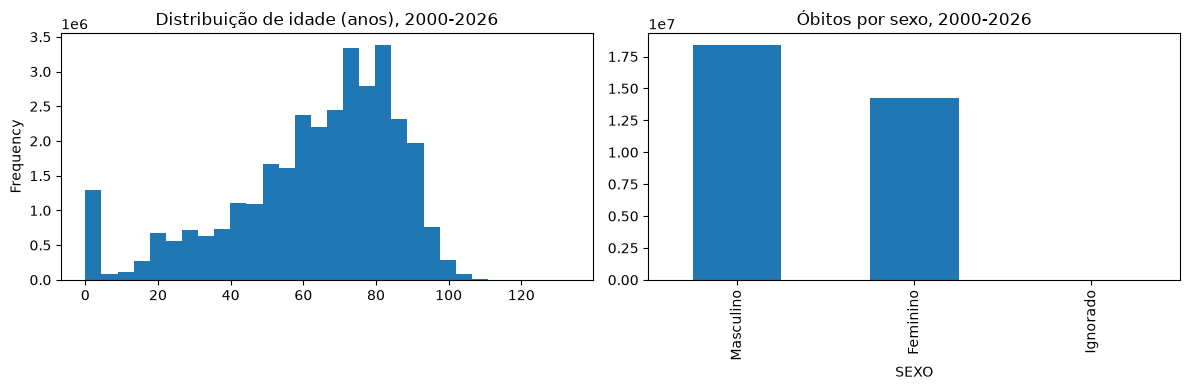

In [4]:
import matplotlib.pyplot as plt

df["idade_anos"] = df["IDADE"].apply(decode_idade_anos)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["idade_anos"].dropna().plot(kind="hist", bins=30, ax=axes[0], title="Distribuição de idade (anos), 2000-2026")
df["SEXO"].map({0: "Ignorado", 1: "Masculino", 2: "Feminino"}).value_counts().plot(
    kind="bar", ax=axes[1], title="Óbitos por sexo, 2000-2026"
)
plt.tight_layout()

Participação (%) de cada capítulo, pooled 2000-2026:


capitulo_desc
Doenças do aparelho circulatório                                      26.96
Neoplasias (tumores)                                                  15.66
Causas externas de morbidade e mortalidade                            11.52
Doenças do aparelho respiratório                                      10.79
Sintomas, sinais e achados anormais, causas mal definidas              7.19
Doenças infecciosas e parasitárias                                     6.47
Doenças endócrinas, nutricionais e metabólicas                         5.82
Doenças do aparelho digestivo                                          4.96
Doenças do aparelho geniturinário                                      2.70
Doenças do sistema nervoso                                             2.62
Afecções originadas no período perinatal                               1.95
Transtornos mentais e comportamentais                                  1.03
Malformações congênitas, deformidades e anomalias cromossômicas        0.8

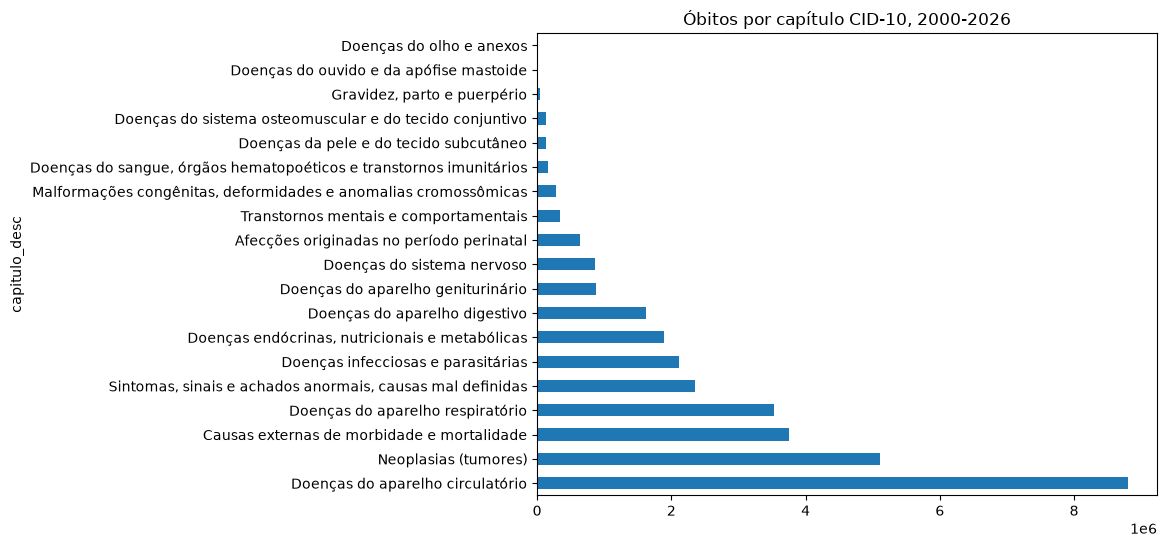

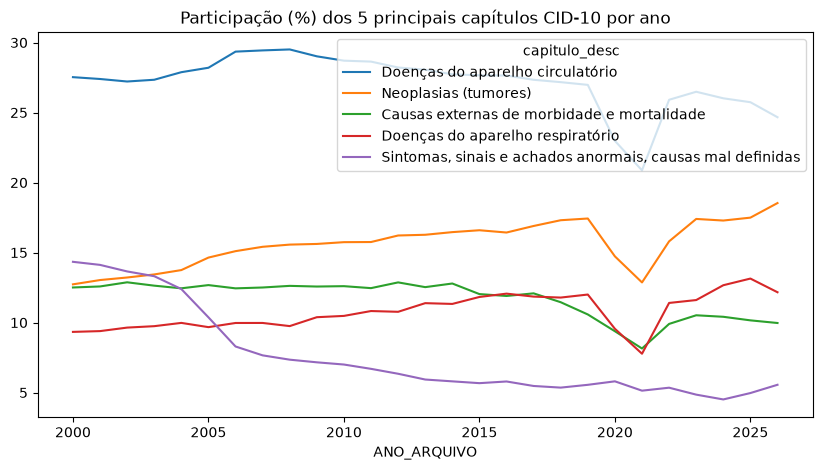

In [5]:
# causabas_to_chapter é aplicada uma vez por código CAUSABAS único (alguns
# milhares), não uma vez por linha (~32 milhões): mesmo resultado, com uma
# fração do tempo e da memória (um pd.Series por linha estoura a RAM).
mapa_capitulo = {c: causabas_to_chapter(c) for c in df["CAUSABAS"].unique()}
df["capitulo_cid10"] = df["CAUSABAS"].map({c: v[0] for c, v in mapa_capitulo.items()})
df["capitulo_desc"] = df["CAUSABAS"].map({c: v[1] for c, v in mapa_capitulo.items()})
df["capitulo_desc"].value_counts().plot(kind="barh", figsize=(8, 6), title="Óbitos por capítulo CID-10, 2000-2026")

# Tendência: participação de cada capítulo ao longo dos anos (2026 é parcial,
# então normalizamos por total do ano, não por contagem absoluta)
tendencia = pd.crosstab(df["ANO_ARQUIVO"], df["capitulo_desc"], normalize="index") * 100
top5_capitulos = df["capitulo_desc"].value_counts().head(5).index
tendencia[top5_capitulos].plot(figsize=(10, 5), title="Participação (%) dos 5 principais capítulos CID-10 por ano")

print("Participação (%) de cada capítulo, pooled 2000-2026:")
print((df["capitulo_desc"].value_counts(normalize=True) * 100).round(2).to_string())
print("Sem capítulo CID-10 (código não interpretável):", df["capitulo_desc"].isna().sum())
print("Participação (%) dos 5 principais capítulos, primeiro e último ano completo:")
print(tendencia.loc[[2000, 2025], top5_capitulos].round(2).T.to_string())

% ausente por ano:
             RACACOR    ESC
ANO_ARQUIVO                
2000           15.90  19.55
2001           13.73  18.45
2002           11.98  16.78
2003           10.31  22.82
2004            9.41  21.95
2005            8.52  21.02
2006            8.80  22.64
2007            8.08  21.52
2008            7.39  20.41
2009            7.17  19.06
2010            6.42  16.45
2011            5.96   9.33
2012            5.53   7.62
2013            5.54  14.28
2014            4.94   7.03
2015            4.50  11.77
2016            3.98  10.55
2017            3.10   9.64
2018            2.83   8.89
2019            2.55   7.75
2020            2.61   7.35
2021            2.31   6.50
2022            1.87   6.41
2023            1.58   6.12
2024            1.33   5.58
2025            1.28   5.08
2026            1.23   4.89
Top 10 CODMUNRES (município de residência, pooled):
CODMUNRES
355030     1582045
330455     1158908
3550308     402236
292740      342387
310620      327756
230440      

Óbitos por mês ('00' = mês ausente/inválido na data):


DTOBITO
00        497
01    2774731
02    2518253
03    2817800
04    2757229
05    2894670
06    2819237
07    2910553
08    2780507
09    2605774
10    2630017
11    2488783
12    2631020


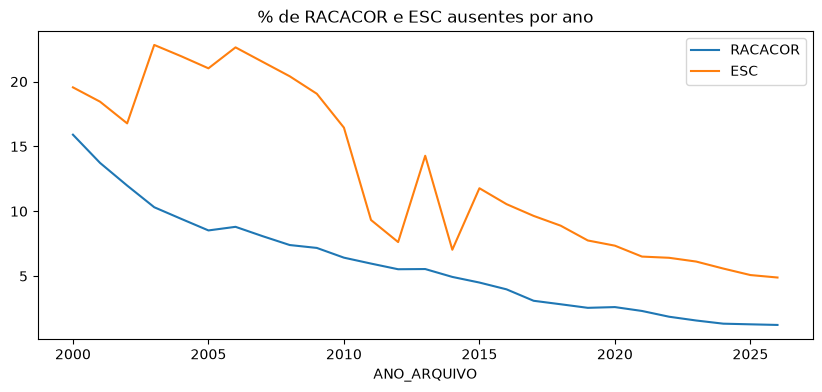

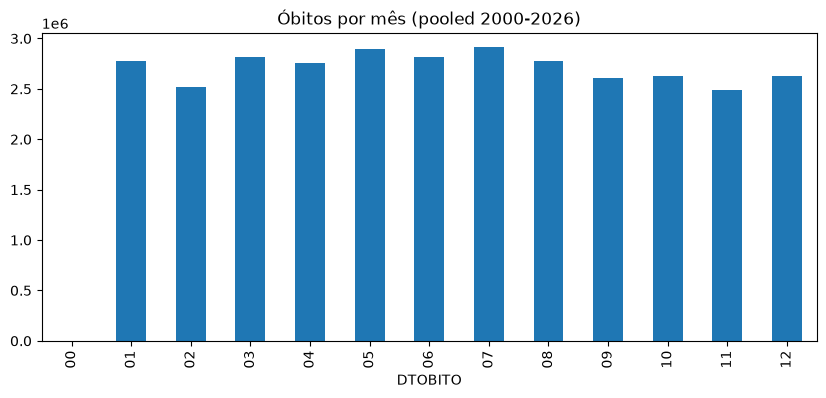

In [6]:
faltantes_por_ano = df.groupby("ANO_ARQUIVO")[["RACACOR", "ESC"]].apply(lambda g: g.isna().mean() * 100)
fig_falt, ax_falt = plt.subplots(figsize=(10, 4))
faltantes_por_ano.plot(ax=ax_falt, title="% de RACACOR e ESC ausentes por ano")
print("% ausente por ano:")
print(faltantes_por_ano.round(2).to_string())

print("Top 10 CODMUNRES (município de residência, pooled):")
print(df["CODMUNRES"].value_counts().head(10).to_string())  # município de residência mais frequente, pooled
mes = df["DTOBITO"].astype(str).str.zfill(8).str[2:4]
fig_mes, ax_mes = plt.subplots(figsize=(10, 4))
mes.value_counts().sort_index().plot(kind="bar", ax=ax_mes, title="Óbitos por mês (pooled 2000-2026)")
print("Óbitos por mês ('00' = mês ausente/inválido na data):")
print(mes.value_counts().sort_index().to_string())